In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [9]:
df_annual_deaths = pd.read_csv("data/annual_deaths_by_clinic.csv")
df_annual_deaths

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [10]:
df_monthly_deaths = pd.read_csv("data/monthly_deaths.csv")
df_monthly_deaths

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
...,...,...,...
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12


In [11]:
df_monthly_deaths.shape

(98, 3)

In [12]:
df_annual_deaths.shape

(12, 4)

In [13]:
df_annual_deaths.columns

Index(['year', 'births', 'deaths', 'clinic'], dtype='str')

In [14]:
df_monthly_deaths.columns

Index(['date', 'births', 'deaths'], dtype='str')

In [15]:
df_monthly_deaths.isna().sum()

date      0
births    0
deaths    0
dtype: int64

In [16]:
df_annual_deaths.isna().sum()

year      0
births    0
deaths    0
clinic    0
dtype: int64

In [17]:
df_annual_deaths.duplicated().sum()

np.int64(0)

In [18]:
df_monthly_deaths.duplicated().sum()

np.int64(0)

In [19]:
df_annual_deaths.groupby("year")["births"].mean()

year
1841    2739.0
1842    2973.0
1843    2899.5
1844    3056.5
1845    3366.5
1846    3882.0
Name: births, dtype: float64

In [20]:
df_annual_deaths.groupby("year")["deaths"].mean()

year
1841    161.5
1842    360.0
1843    219.0
1844    164.0
1845    153.5
1846    282.0
Name: deaths, dtype: float64

In [21]:
df_monthly_deaths.describe()

,births,deaths
count,98.000000,98.000000
mean,267.000000,22.469388
std,41.769372,18.141031
min,190.000000,0.000000
25%,242.500000,8.000000
50%,264.000000,16.500000
75%,292.750000,36.750000
max,406.000000,75.000000


In [22]:
df_annual_deaths

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [23]:
df_annual_deaths.dtypes

year      int64
births    int64
deaths    int64
clinic      str
dtype: object

In [28]:
death_pct = (df_annual_deaths.deaths.sum()/ df_annual_deaths.births.sum())*100
death_pct

np.float64(7.083762852536147)

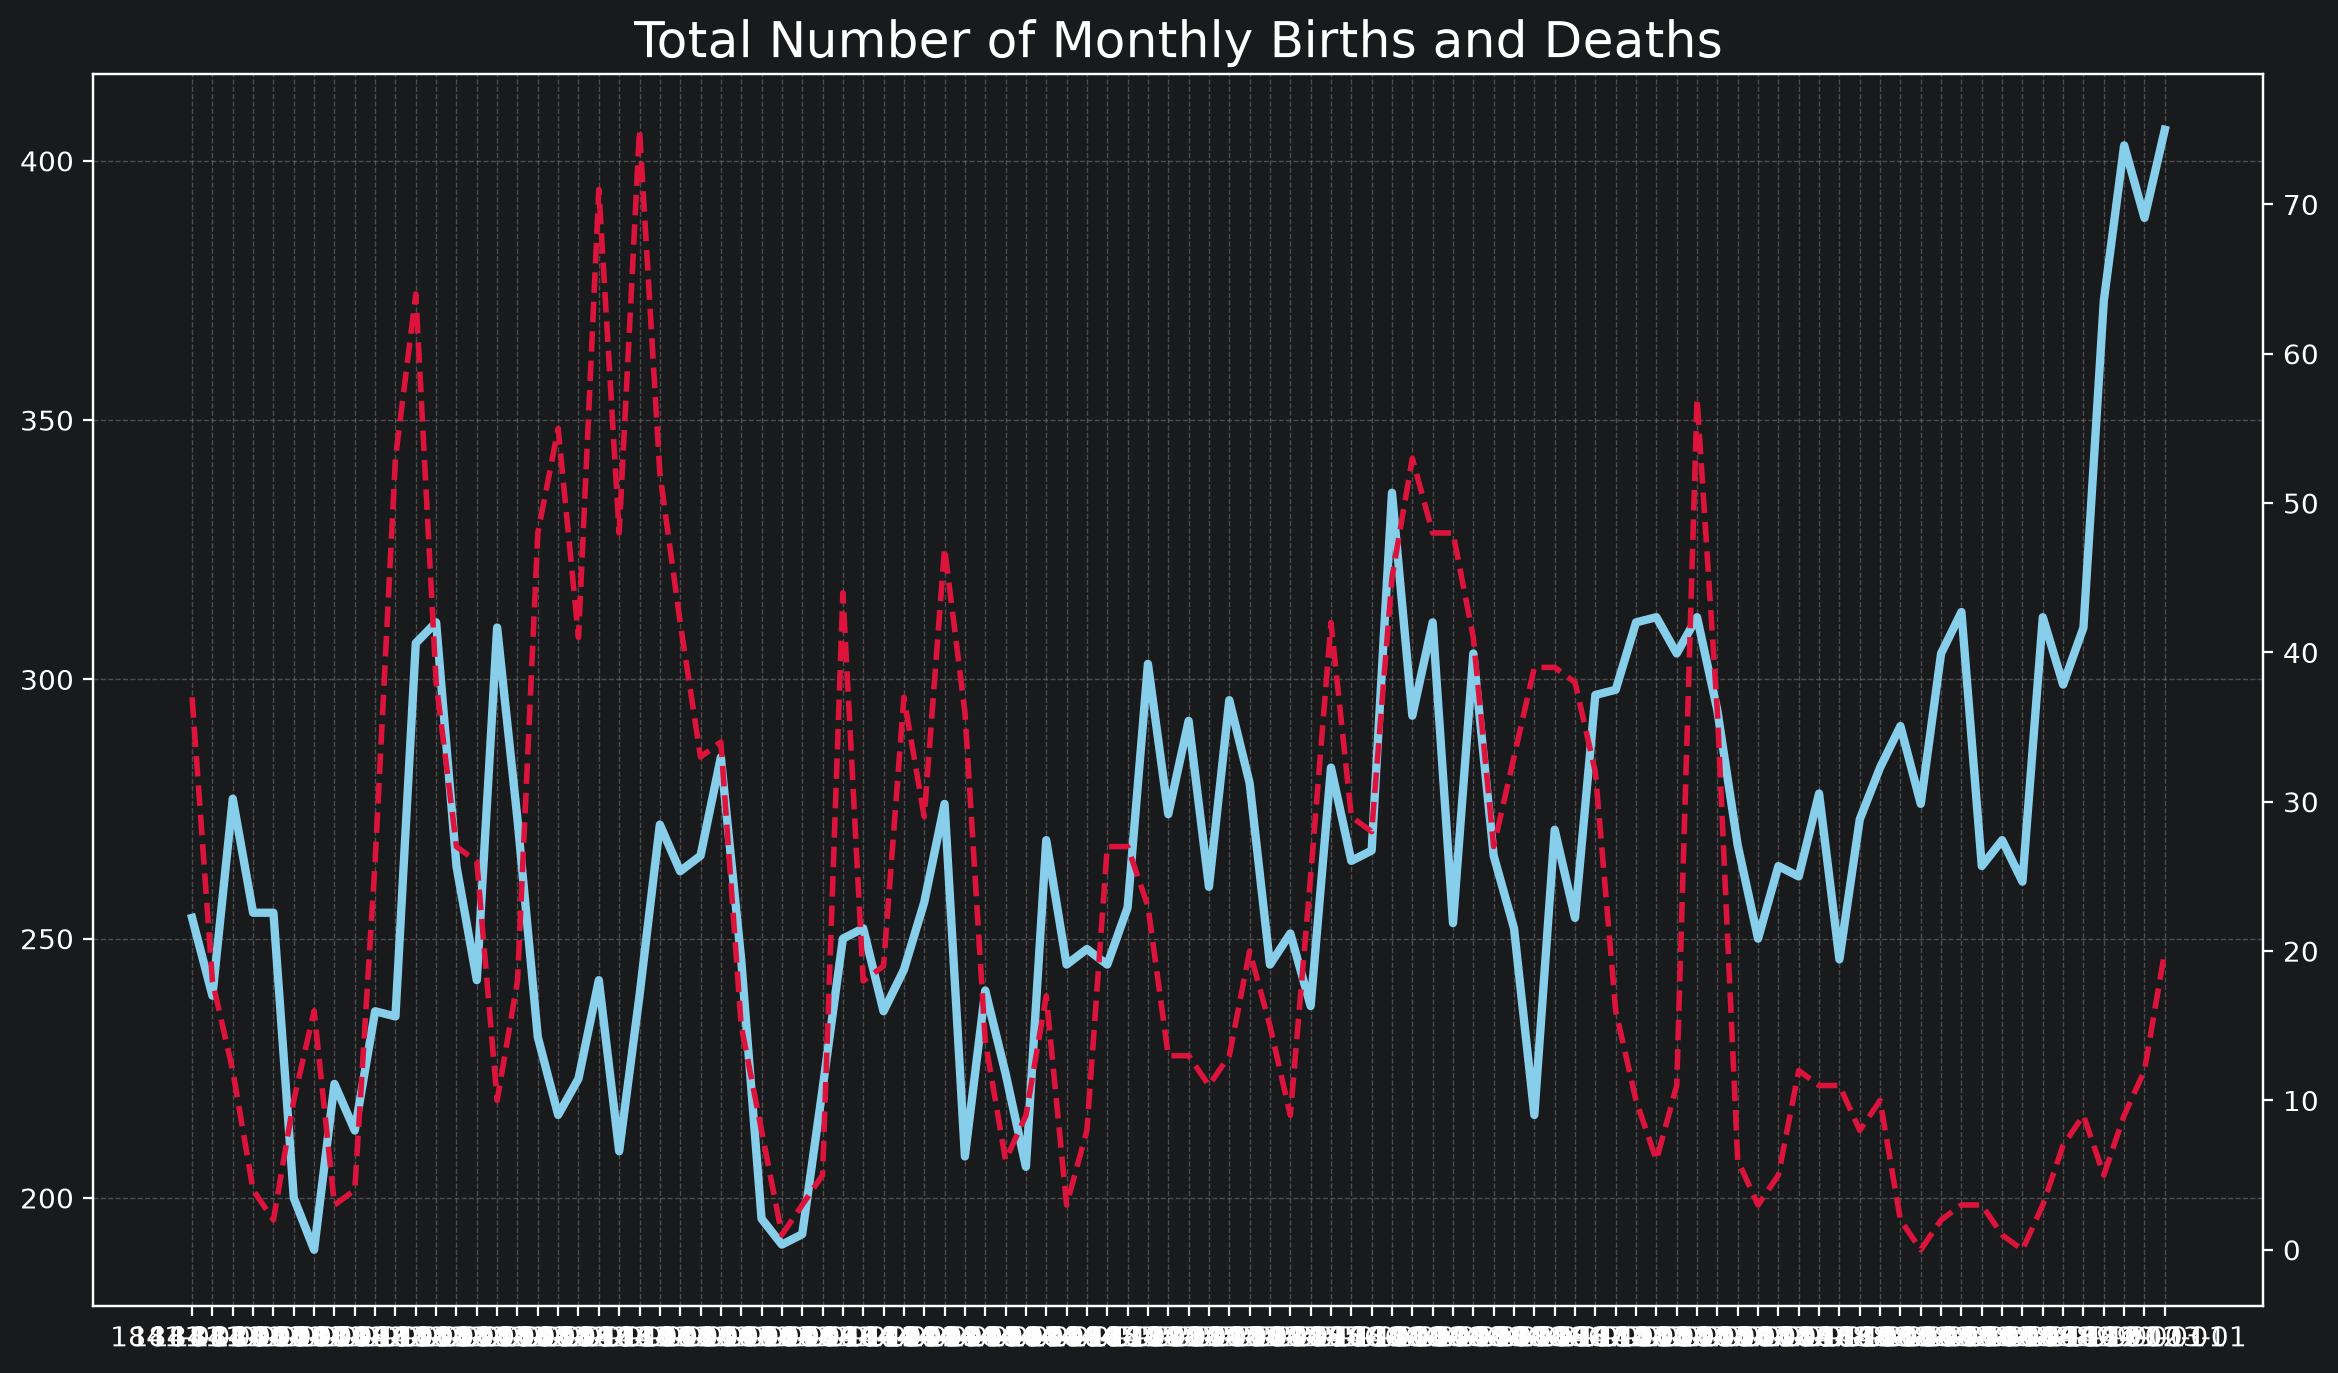

In [32]:
plt.figure(figsize=(14,8), dpi=200)
plt.title('Total Number of Monthly Births and Deaths', fontsize=18)
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.grid(color="grey",linestyle = "--")

ax1.plot(df_monthly_deaths.date,
         df_monthly_deaths.births,
         color="skyblue",
         linewidth = 3)

ax2.plot(df_monthly_deaths.date,
         df_monthly_deaths.deaths,
         color='crimson',
         linewidth=2,
         linestyle='--')

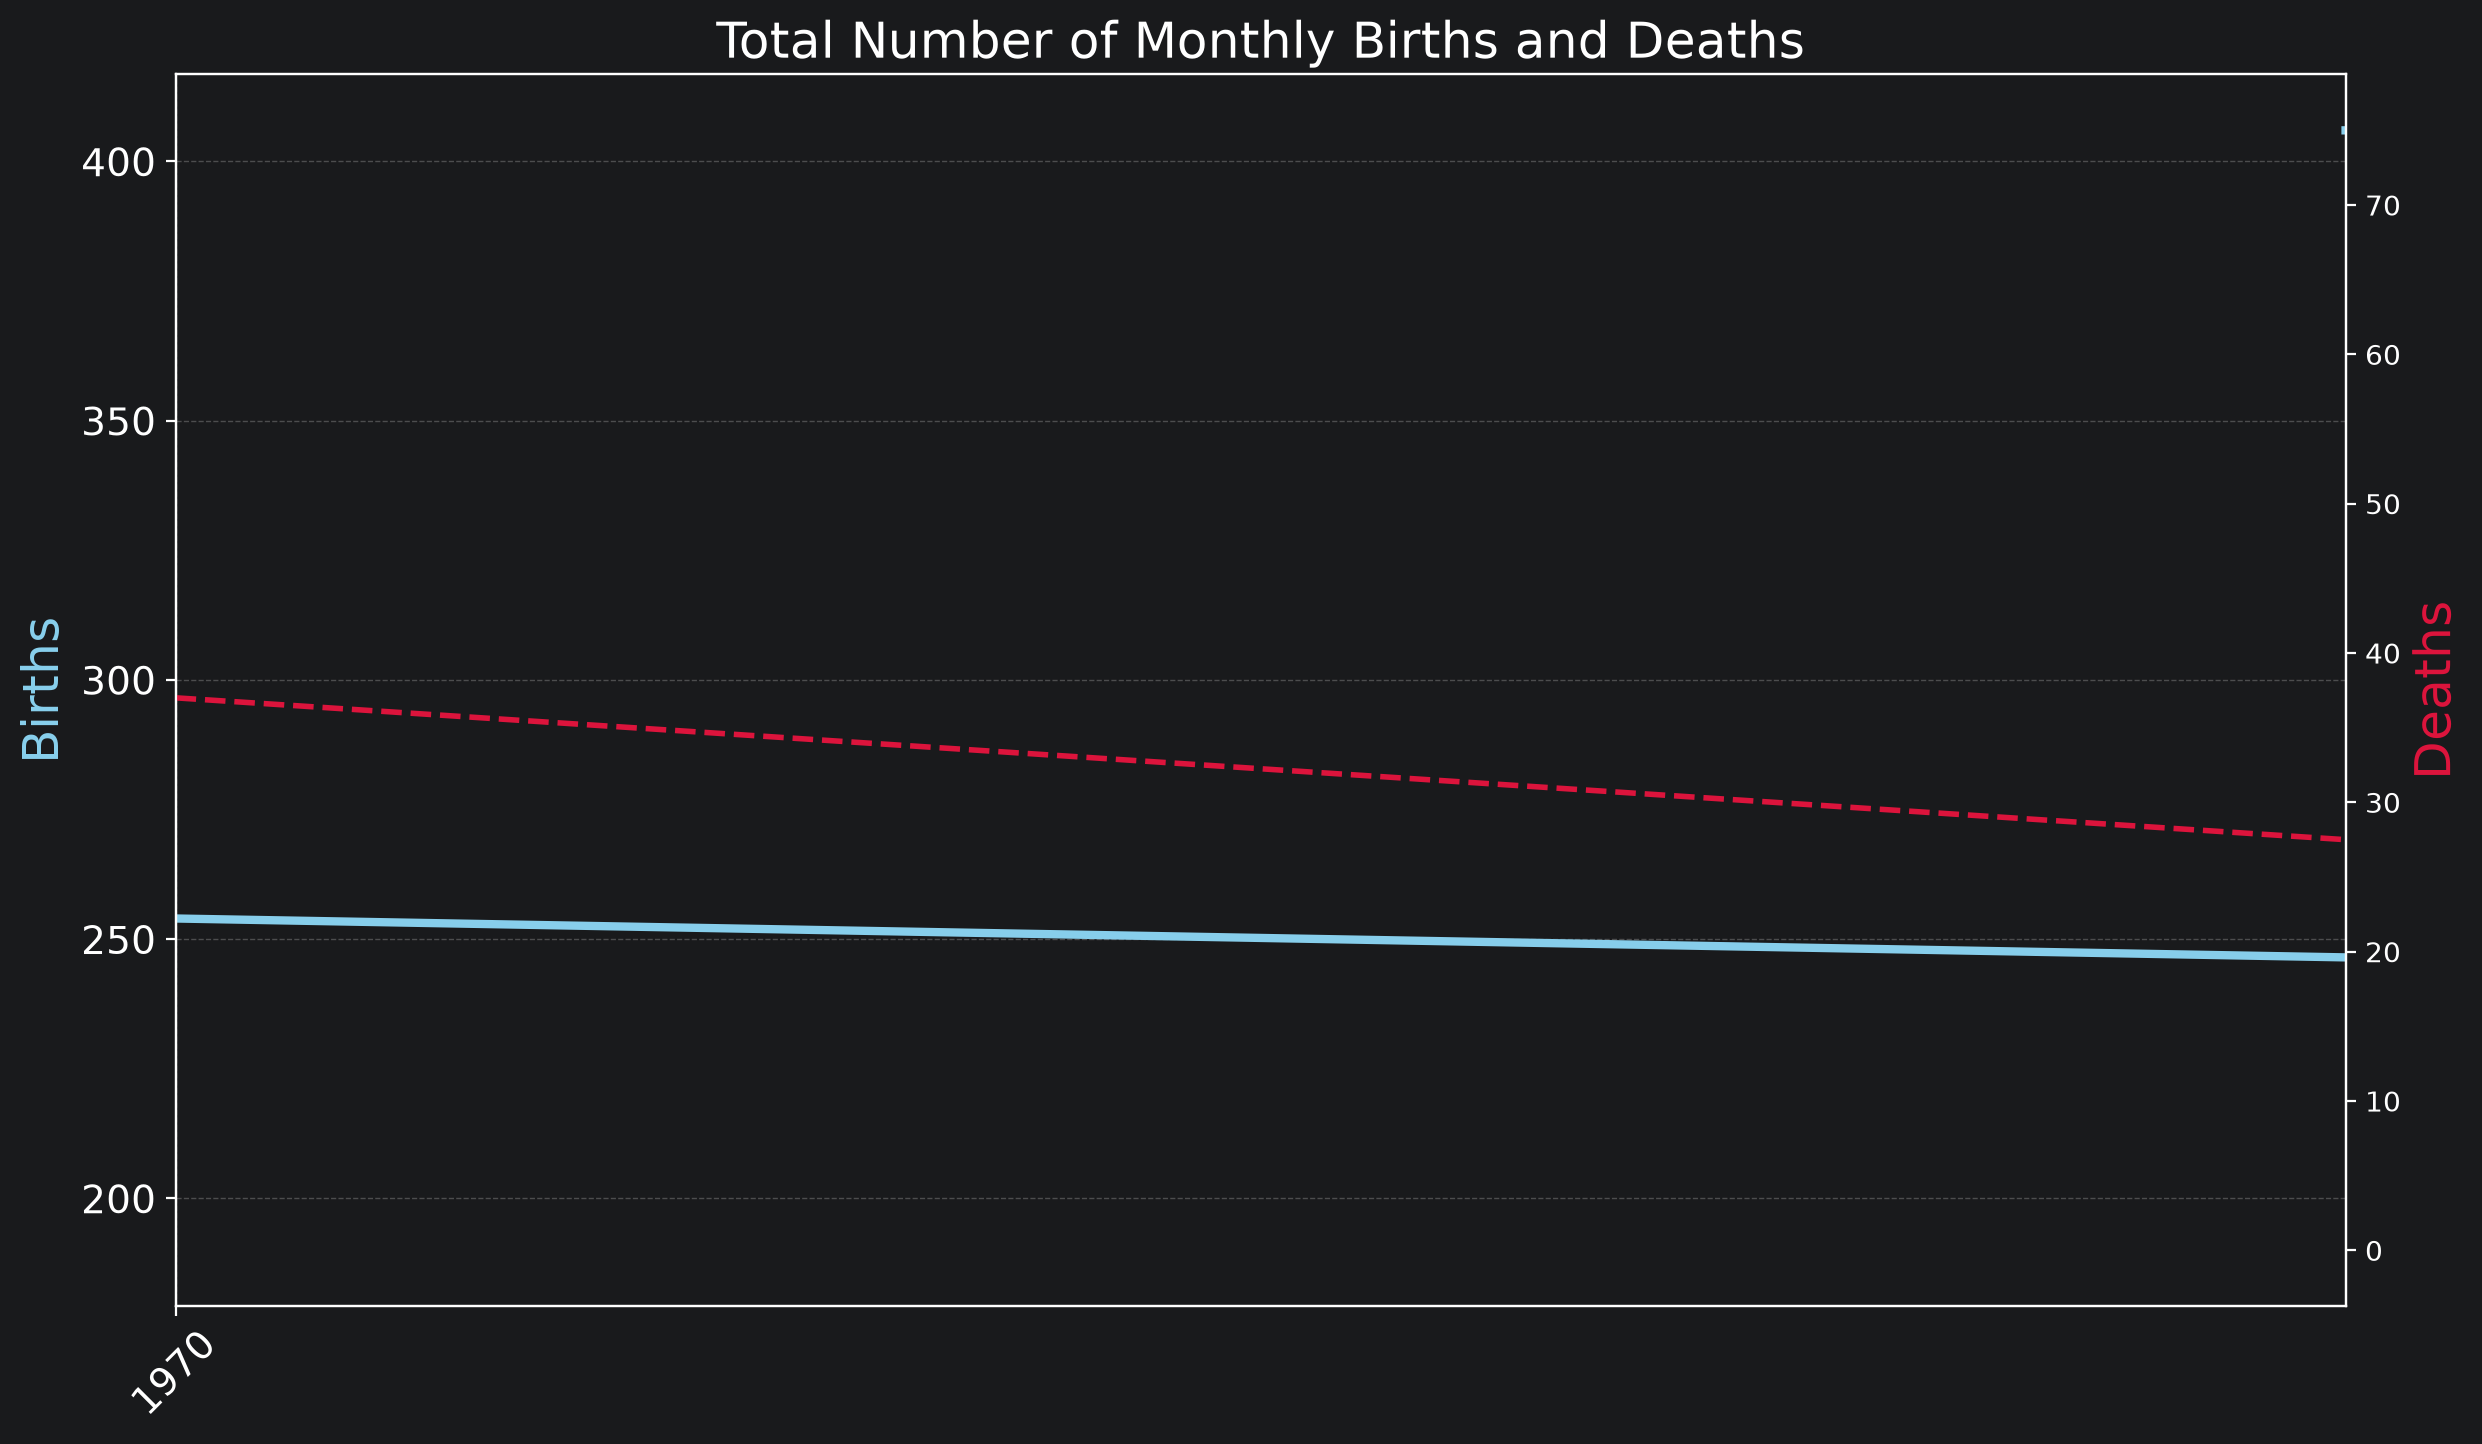

In [36]:
# Create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

plt.figure(figsize=(14,8), dpi=200)
plt.title('Total Number of Monthly Births and Deaths', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('Births', color='skyblue', fontsize=18)
ax2.set_ylabel('Deaths', color='crimson', fontsize=18)

# Use Locators
ax1.set_xlim([df_monthly_deaths.date.min(), df_monthly_deaths.date.max()])
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.grid(color='grey', linestyle='--')

ax1.plot(df_monthly_deaths.date,
         df_monthly_deaths.births,
         color="skyblue",
         linewidth = 3)

ax2.plot(df_monthly_deaths.date,
         df_monthly_deaths.deaths,
         color='crimson',
         linewidth=2,
         linestyle='--')



In [37]:
df_annual_deaths

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [43]:
clinic_1 = df_annual_deaths[df_annual_deaths.clinic == "clinic 1"]
clinic_1

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1


In [39]:
clinic_2 = df_annual_deaths[df_annual_deaths.clinic == "clinic 2"]
clinic_2

,year,births,deaths,clinic
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2
10,1845,3241,66,clinic 2
11,1846,3754,105,clinic 2


In [49]:
line = px.line(df_annual_deaths,
               x='year',
               y='births',
               color='clinic',
               title='Total Yearly Births by Clinic')

line.show()

In [50]:
line = px.line(df_annual_deaths,
               x='year',
               y='deaths',
               color='clinic',
               title='Total Yearly Deaths by Clinic')

line.show()

In [51]:
df_annual_deaths

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [52]:
df_annual_deaths["pct_death"] = (df_annual_deaths.deaths/df_annual_deaths.births)*100

In [53]:
df_annual_deaths

,year,births,deaths,clinic,pct_death
0,1841,3036,237,clinic 1,7.806324
1,1842,3287,518,clinic 1,15.759051
2,1843,3060,274,clinic 1,8.954248
3,1844,3157,260,clinic 1,8.235667
4,1845,3492,241,clinic 1,6.901489
5,1846,4010,459,clinic 1,11.446384
6,1841,2442,86,clinic 2,3.521704
7,1842,2659,202,clinic 2,7.596841
8,1843,2739,164,clinic 2,5.987587
9,1844,2956,68,clinic 2,2.300406


In [55]:
clinic_1 = df_annual_deaths[df_annual_deaths.clinic == "clinic 1"]
clinic_1

,year,births,deaths,clinic,pct_death
0,1841,3036,237,clinic 1,7.806324
1,1842,3287,518,clinic 1,15.759051
2,1843,3060,274,clinic 1,8.954248
3,1844,3157,260,clinic 1,8.235667
4,1845,3492,241,clinic 1,6.901489
5,1846,4010,459,clinic 1,11.446384


In [56]:
clinic_1.describe()

,year,births,deaths,pct_death
count,6.000000,6.000000,6.000000,6.000000
mean,1843.500000,3340.333333,331.500000,9.850527
std,1.870829,368.542354,123.755808,3.278539
min,1841.000000,3036.000000,237.000000,6.901489
25%,1842.250000,3084.250000,245.750000,7.913660
50%,1843.500000,3222.000000,267.000000,8.594958
75%,1844.750000,3440.750000,412.750000,10.823350
max,1846.000000,4010.000000,518.000000,15.759051


In [58]:
clinic_2 = df_annual_deaths[df_annual_deaths.clinic == "clinic 2"]
clinic_2.describe()

,year,births,deaths,pct_death
count,6.000000,6.000000,6.000000,6.000000
mean,1843.500000,2965.166667,115.166667,4.039994
std,1.870829,472.656077,55.715049,2.249374
min,1841.000000,2442.000000,66.000000,2.036409
25%,1842.250000,2679.000000,72.500000,2.424559
50%,1843.500000,2847.500000,95.500000,3.159360
75%,1844.750000,3169.750000,149.250000,5.371116
max,1846.000000,3754.000000,202.000000,7.596841


In [59]:
line = px.line(df_annual_deaths,
               x='year',
               y='pct_death',
               color='clinic',
               title='Total Yearly death percentage by Clinic')

line.show()

In [60]:
df_annual_deaths

,year,births,deaths,clinic,pct_death
0,1841,3036,237,clinic 1,7.806324
1,1842,3287,518,clinic 1,15.759051
2,1843,3060,274,clinic 1,8.954248
3,1844,3157,260,clinic 1,8.235667
4,1845,3492,241,clinic 1,6.901489
5,1846,4010,459,clinic 1,11.446384
6,1841,2442,86,clinic 2,3.521704
7,1842,2659,202,clinic 2,7.596841
8,1843,2739,164,clinic 2,5.987587
9,1844,2956,68,clinic 2,2.300406


In [61]:
df_monthly_deaths

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
...,...,...,...
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12


In [62]:
df_monthly_deaths['pct_deaths'] = (df_monthly_deaths.deaths/df_monthly_deaths.births)*100

In [63]:
df_monthly_deaths

,date,births,deaths,pct_deaths
0,1841-01-01,254,37,14.566929
1,1841-02-01,239,18,7.531381
2,1841-03-01,277,12,4.332130
3,1841-04-01,255,4,1.568627
4,1841-05-01,255,2,0.784314
...,...,...,...,...
93,1848-11-01,310,9,2.903226
94,1848-12-01,373,5,1.340483
95,1849-01-01,403,9,2.233251
96,1849-02-01,389,12,3.084833


In [67]:
before_handwashing = df_monthly_deaths[df_monthly_deaths.date < "1847-01-01"]
before_handwashing

,date,births,deaths,pct_deaths
0,1841-01-01,254,37,14.566929
1,1841-02-01,239,18,7.531381
2,1841-03-01,277,12,4.332130
3,1841-04-01,255,4,1.568627
4,1841-05-01,255,2,0.784314
...,...,...,...,...
66,1846-08-01,216,39,18.055556
67,1846-09-01,271,39,14.391144
68,1846-10-01,254,38,14.960630
69,1846-11-01,297,32,10.774411


In [66]:
after_handwashing = df_monthly_deaths[df_monthly_deaths.date >= "1847-01-01"]
after_handwashing

,date,births,deaths,pct_deaths
71,1847-01-01,311,10,3.215434
72,1847-02-01,312,6,1.923077
73,1847-03-01,305,11,3.606557
74,1847-04-01,312,57,18.269231
75,1847-05-01,294,36,12.244898
76,1847-06-01,268,6,2.238806
77,1847-07-01,250,3,1.200000
78,1847-08-01,264,5,1.893939
79,1847-09-01,262,12,4.580153
80,1847-10-01,278,11,3.956835


In [68]:
before_handwashing.describe()

,births,deaths,pct_deaths
count,71.000000,71.000000,71.000000
mean,254.042254,27.323944,10.691840
std,32.705367,17.789864,7.082951
min,190.000000,1.000000,0.523560
25%,236.000000,13.000000,4.598290
50%,253.000000,27.000000,10.546875
75%,273.500000,40.000000,15.062282
max,336.000000,75.000000,31.380753


In [69]:
after_handwashing.describe()

,births,deaths,pct_deaths
count,27.000000,27.000000,27.000000
mean,301.074074,9.703704,3.172764
std,44.328256,11.922231,3.849808
min,246.000000,0.000000,0.000000
25%,268.500000,3.000000,1.048951
50%,294.000000,7.000000,2.238806
75%,312.000000,11.000000,3.570063
max,406.000000,57.000000,18.269231


In [70]:
bw_rate = before_handwashing.deaths.sum() / before_handwashing.births.sum() * 100
bw_rate

np.float64(10.75566890281089)

In [71]:
roll_df = before_handwashing.set_index('date')
roll_df

,births,deaths,pct_deaths
date,,,
1841-01-01,254,37,14.566929
1841-02-01,239,18,7.531381
1841-03-01,277,12,4.332130
1841-04-01,255,4,1.568627
1841-05-01,255,2,0.784314
...,...,...,...
1846-08-01,216,39,18.055556
1846-09-01,271,39,14.391144
1846-10-01,254,38,14.960630


In [73]:
roll_df = roll_df.rolling(window=6).mean()
roll_df

,births,deaths,pct_deaths
date,,,
1841-01-01,NaN,NaN,NaN
1841-02-01,NaN,NaN,NaN
1841-03-01,NaN,NaN,NaN
1841-04-01,NaN,NaN,NaN
1841-05-01,NaN,NaN,NaN
...,...,...,...
1846-08-01,285.888889,41.861111,14.670483
1846-09-01,280.555556,41.361111,14.807158
1846-10-01,276.083333,40.416667,14.717638


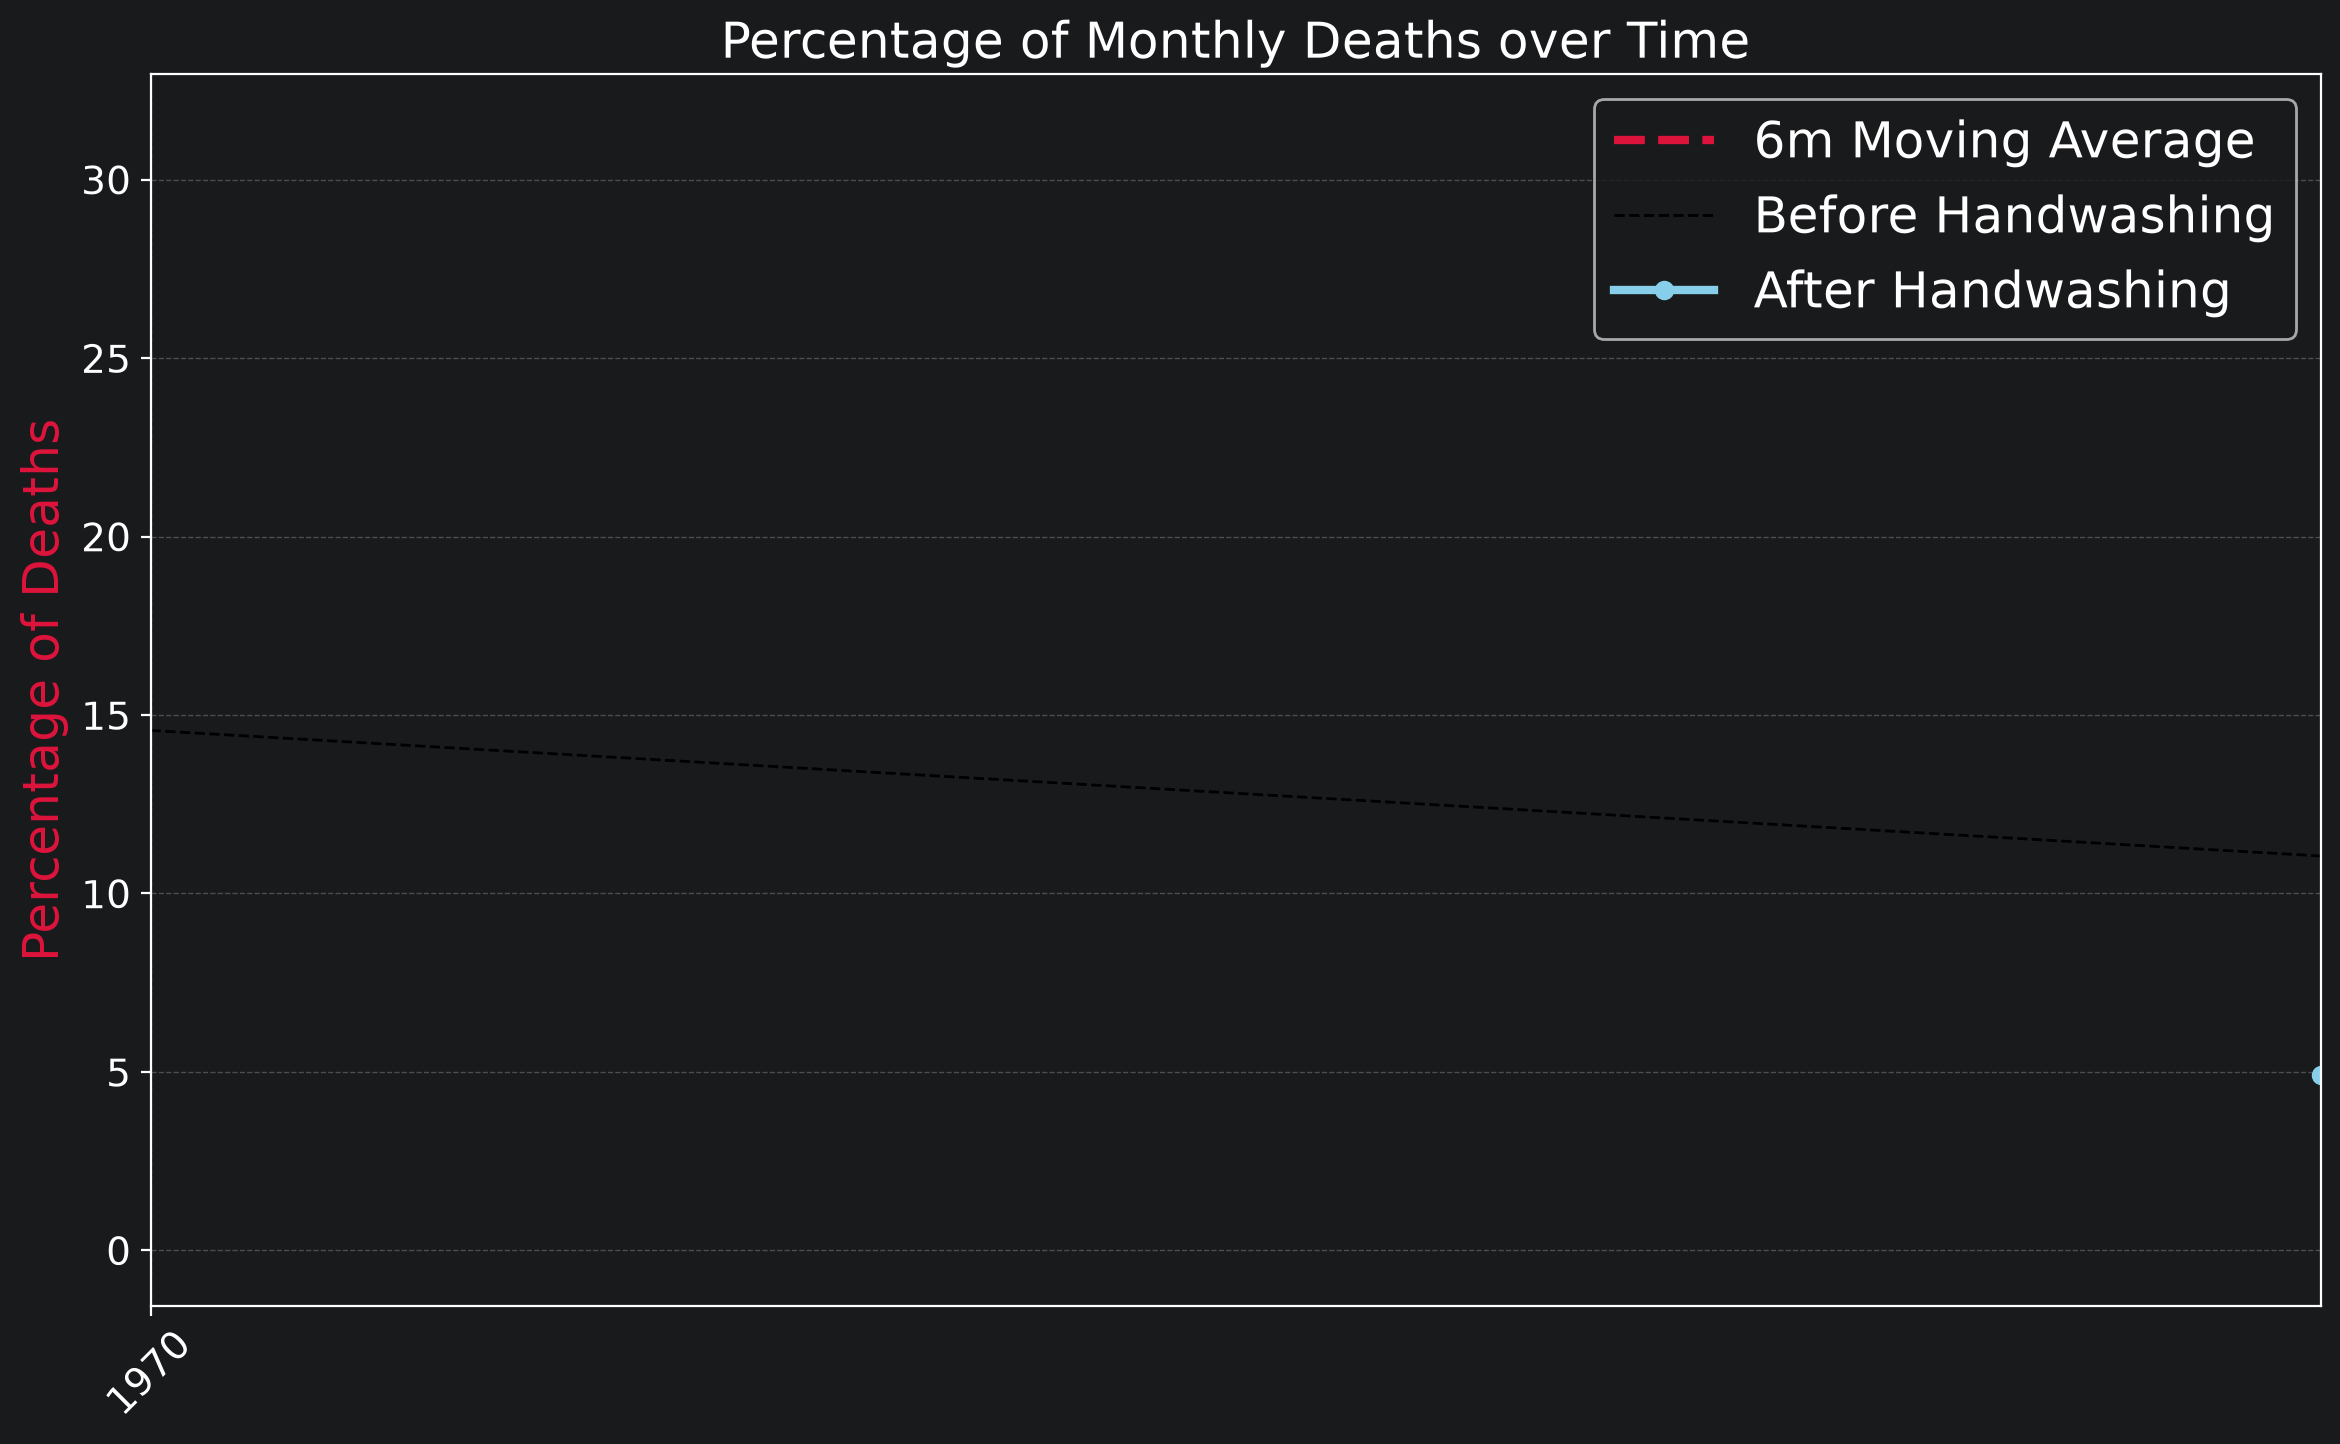

In [74]:
# Create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

plt.figure(figsize=(14,8), dpi=200)
plt.title('Percentage of Monthly Deaths over Time', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

plt.ylabel('Percentage of Deaths', color='crimson', fontsize=18)

ax = plt.gca()
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.xaxis.set_minor_locator(months)
ax.set_xlim([df_monthly_deaths.date.min(), df_monthly_deaths.date.max()])

plt.grid(color='grey', linestyle='--')

ma_line, = plt.plot(roll_df.index,
                    roll_df.pct_deaths,
                    color='crimson',
                    linewidth=3,
                    linestyle='--',
                    label='6m Moving Average')
bw_line, = plt.plot(before_handwashing.date,
                    before_handwashing.pct_deaths,
                    color='black',
                    linewidth=1,
                    linestyle='--',
                    label='Before Handwashing')
aw_line, = plt.plot(after_handwashing.date,
                    after_handwashing.pct_deaths,
                    color='skyblue',
                    linewidth=3,
                    marker='o',
                    label='After Handwashing')

plt.legend(handles=[ma_line, bw_line, aw_line],
           fontsize=18)

plt.show()


In [76]:
df_monthly_deaths['washing_hands'] = np.where(df_monthly_deaths.date < "1847-01-01", 'No', 'Yes')

In [77]:
box = px.box(df_monthly_deaths,
             x='washing_hands',
             y='pct_deaths',
             color='washing_hands',
             title='How Have the Stats Changed with Handwashing?')

box.update_layout(xaxis_title='Washing Hands?',
                  yaxis_title='Percentage of Monthly Deaths',)

box.show()

In [78]:
hist = px.histogram(df_monthly_deaths,
                   x='pct_deaths',
                   color='washing_hands',
                   nbins=30,
                   opacity=0.6,
                   barmode='overlay',
                   histnorm='percent',
                   marginal='box',)

hist.update_layout(xaxis_title='Proportion of Monthly Deaths',
                   yaxis_title='Count',)

hist.show()

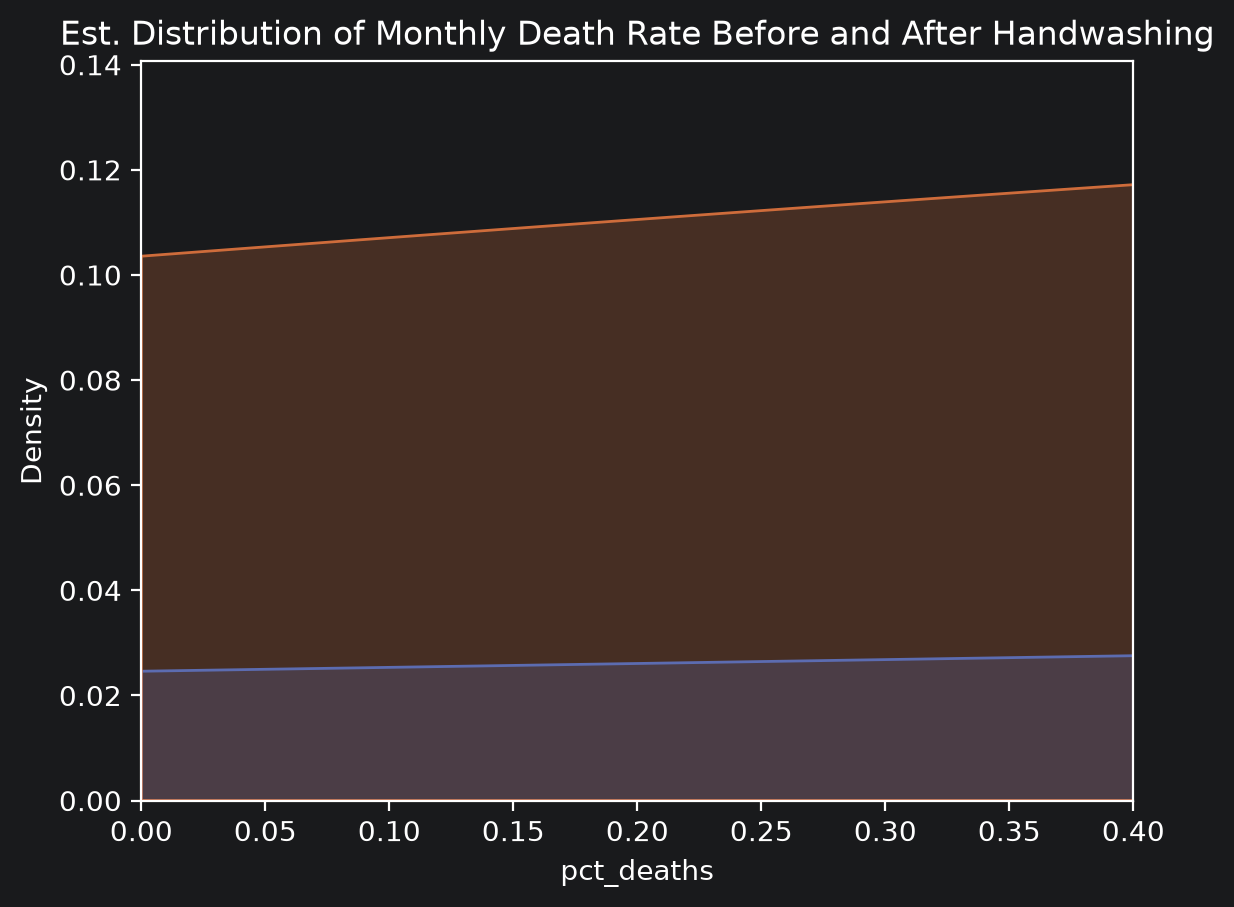

In [82]:
plt.figure(dpi=200)
sns.kdeplot(before_handwashing.pct_deaths,
            fill=True,
            clip=(0,1))
sns.kdeplot(after_handwashing.pct_deaths,
            fill=True,
            clip=(0,1))
plt.title('Est. Distribution of Monthly Death Rate Before and After Handwashing')
plt.xlim(0, 0.40)
plt.show()

In [87]:
t_stat, p_value = stats.ttest_ind(
    a=before_handwashing.pct_deaths,
    b=after_handwashing.pct_deaths
)

print(f'p-value is {p_value:.10f}')
print(f't-statistic is {t_stat:.4f}')

p-value is 0.0000010362
t-statistic is 5.2195
